In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
def unet_block(x, f):
    x = layers.Conv2D(f, (3,3), activation="relu", padding="same")(x)
    x = layers.Conv2D(f, (3,3), activation="relu", padding="same")(x)
    return x

def build_unet(input_shape=(128,128,3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    c1 = unet_block(inputs, 64)
    p1 = layers.MaxPooling2D((2,2))(c1)

    c2 = unet_block(p1, 128)
    p2 = layers.MaxPooling2D((2,2))(c2)

    bn = unet_block(p2, 256)

    u1 = layers.UpSampling2D((2,2))(bn)
    u1 = layers.Concatenate()([u1, c2])
    c3 = unet_block(u1, 128)

    u2 = layers.UpSampling2D((2,2))(c3)
    u2 = layers.Concatenate()([u2, c1])
    c4 = unet_block(u2, 64)

    outputs = layers.Conv2D(num_classes, (1,1), activation="sigmoid")(c4)

    return models.Model(inputs, outputs)

In [ ]:
model_demo = build_unet()
model_demo.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 128, 128,  │      1,792 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_44[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ conv2d_45[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_46[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ conv2d_47[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_9[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_48[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_8     │ (None, 64, 64,    │          0 │ conv2d_49[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 64, 64,    │          0 │ up_sampling2d_8[… │
│ (Concatenate)       │ 384)              │            │ conv2d_47[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 64, 64,    │    442,496 │ concatenate_8[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_50[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_9     │ (None, 128, 128,  │          0 │ conv2d_51[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 128, 128,  │          0 │ up_sampling2d_9[… │
│ (Concatenate)       │ 192)              │            │ conv2d_45[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 128, 128,  │    110,656 │ concatenate_9[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_52[0][0] 

 Total params: 1,883,137 (7.18 MB)

 Trainable params: 1,883,137 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

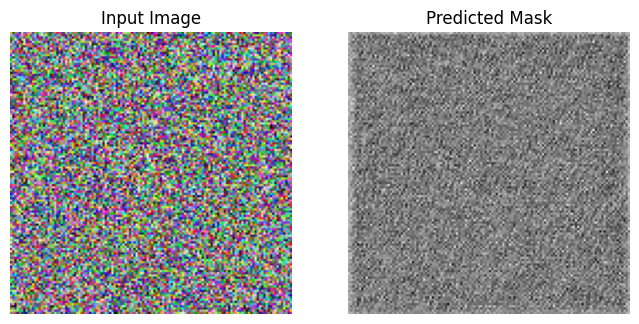

In [ ]:
img = tf.random.uniform((1,128,128,3))
pred_mask = model_demo(img)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pred_mask[0,:,:,0], cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")
plt.show()

In [ ]:
dataset = tfds.load("oxford_iiit_pet", with_info=False)

train_ds = dataset["train"]
test_ds = dataset["test"]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.BCTVO1_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.BCTVO1_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [ ]:
IMG_SIZE = 64

def preprocess(sample):
    img = sample["image"]
    mask = sample["segmentation_mask"]

    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE), method="nearest")
    mask = tf.cast(mask, tf.int32)
    mask = mask - 1
    mask = tf.cast(mask, tf.float32)

    return img, mask

In [ ]:
BATCH = 16

train_data = train_ds.map(preprocess).shuffle(1000).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_data = test_ds.map(preprocess).batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [ ]:
def iou(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

In [ ]:
model = build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=1)

model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy", iou])

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 64, 64,    │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_33[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ conv2d_34[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_35[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ conv2d_36[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_7[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 16, 16,    │    590,080 │ conv2d_37[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_6     │ (None, 32, 32,    │          0 │ conv2d_38[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 32, 32,    │          0 │ up_sampling2d_6[… │
│ (Concatenate)       │ 384)              │            │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 32, 32,    │    442,496 │ concatenate_6[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_39[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_7     │ (None, 64, 64,    │          0 │ conv2d_40[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 64, 64,    │          0 │ up_sampling2d_7[… │
│ (Concatenate)       │ 192)              │            │ conv2d_34[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 64, 64,    │    110,656 │ concatenate_7[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_41[0][0] 

 Total params: 1,883,137 (7.18 MB)

 Trainable params: 1,883,137 (7.18 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
EPOCHS = 10

start = time.time()
history = model.fit(train_data, validation_data=test_data, epochs=EPOCHS)
train_time = time.time() - start

print("Training Time:", train_time)

Epoch 1/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 35s 96ms/step - accuracy: 0.5710 - iou: 0.7459 - loss: -1715264552960.0000 - val_accuracy: 0.4367 - val_iou: 0.2461 - val_loss: -1042981670879232.0000
Epoch 2/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.5241 - iou: 0.6062 - loss: nan - val_accuracy: 0.2999 - val_iou: 0.0000e+00 - val_loss: nan
Epoch 3/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.2991 - iou: 0.0000e+00 - loss: nan - val_accuracy: 0.2999 - val_iou: 0.0000e+00 - val_loss: nan
Epoch 4/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.2978 - iou: 0.0000e+00 - loss: nan - val_accuracy: 0.2999 - val_iou: 0.0000e+00 - val_loss: nan
Epoch 5/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.2936 - iou: 0.0000e+00 - loss: nan - val_accuracy: 0.2999 - val_iou: 0.0000e+00 - val_loss: nan
Epoch 6/10
230/230 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.2946 - iou: 0.0000e+00 - loss: nan - val_accuracy: 0.2999 - val_iou: 0.0000e+00 - val_los

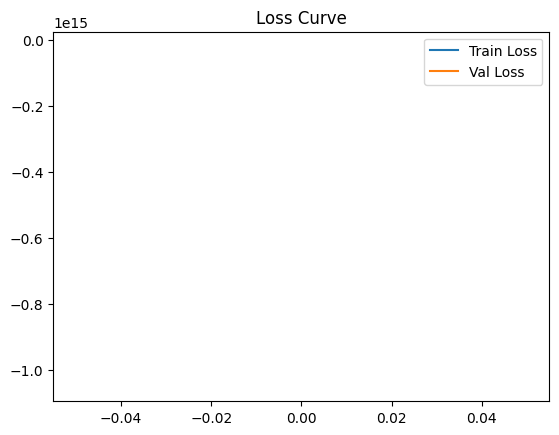

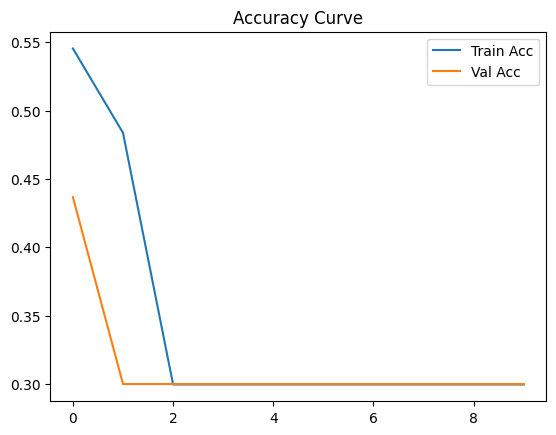

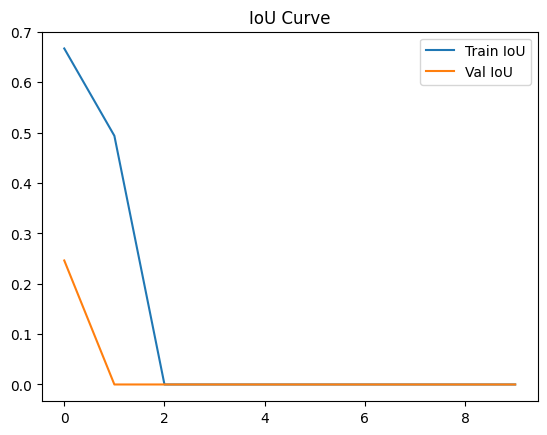

In [ ]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.plot(history.history["iou"], label="Train IoU")
plt.plot(history.history["val_iou"], label="Val IoU")
plt.legend()
plt.title("IoU Curve")
plt.show()

In [ ]:
model.evaluate(test_data)

230/230 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.3015 - iou: 0.0000e+00 - loss: nan


[nan, 0.299868643283844, 0.0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step


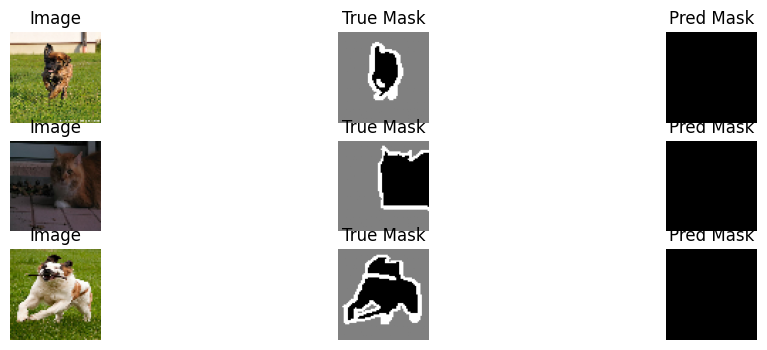

In [ ]:
for img, mask in test_data.take(1):
    pred = model.predict(img)
    pred = (pred > 0.5).astype(np.uint8)

    plt.figure(figsize=(12,4))
    for i in range(3):
        plt.subplot(3,3,3*i+1)
        plt.imshow(img[i])
        plt.title("Image")
        plt.axis("off")

        plt.subplot(3,3,3*i+2)
        plt.imshow(mask[i,:,:,0], cmap="gray")
        plt.title("True Mask")
        plt.axis("off")

        plt.subplot(3,3,3*i+3)
        plt.imshow(pred[i,:,:,0], cmap="gray")
        plt.title("Pred Mask")
        plt.axis("off")

    plt.show()
    break

In [ ]:
model.save("unet_model.keras")